# Super-Resolving the Weather with Q-SRDRN

Climate models and reanalyses paint the weather in **big chunky squares** — about 25 km across for ERA5, the best global atmospheric reanalysis we have. That's too coarse to see what happens at a specific city, farm, or watershed.

The **Q-SRDRN** (Quantile Super-Resolution Deep Residual Network) takes that blurry picture and **sharpens it** to ~4 km — the same idea as upscaling a tiny photo, but for rain. It also produces a **range of possible outcomes** (quantiles) so you know how confident the prediction is.

In this notebook you'll:
1. Load **pre-computed Q-SRDRN downscaled precipitation** for Florida (2015–2019) — already run, no GPU needed.
2. Pick **any day** in that window.
3. Compare the blurry ERA5 input, the sharp downscaled output, and what *actually* happened (PRISM observations).

**Input:**   low-res ERA5 reanalysis (26 × 33 pixels, 15 weather variables, ~25 km)  
**Output:** high-res precipitation map (156 × 132 pixels, ~4 km grid)  
**Already computed** — you're browsing the results, not training or running inference.

---

## Step 0: Install the Libraries

We need **xarray** and **netCDF4** (to read `.nc` files), **NumPy**, **pandas**, and **Matplotlib**. No deep-learning framework required — the model has already been run.

In [ ]:
%pip install --quiet xarray netCDF4 numpy pandas matplotlib
print('Libraries installed.')

---

## Step 1: The Three Datasets

We work with three pieces, all aligned to the same 156 × 132 grid over Florida for 2015–2019 (1,826 days):

**1. Low-res ERA5 predictors** (`mydata_corrected_fl/`)
ERA5 is a global atmospheric reanalysis — the best historical estimate of the atmosphere we have, at 0.25° (~25 km) resolution. We use 15 daily variables over a 26 × 33 grid covering Florida: temperature (2m, min, max), humidity, wind (u, v, 10m speed), precipitation (total, convective), cloud cover (high, low, total), soil temperature, runoff, and evaporation. The precipitation channel (`tp`) is what we'll show in the low-res panel.

**2. Q-SRDRN downscaled output** (`test_precip_mm.nc`)
The model's best-guess (P50 median) daily precipitation, already computed and saved as a netCDF file. Values are in **mm/day** on the high-res 156 × 132 grid.

**3. PRISM observations** (`mydata_corrected_fl/obs_test_mean_std_single.npy`)
The *real* daily precipitation from the PRISM Climate Group — weather station measurements interpolated to the same 4 km grid. This is our truth map. Stored in normalized form; we undo the normalization before plotting.

The ERA5 predictors and PRISM observations were normalized with a **log1p + z-score** transform on precipitation (the same preprocessing the Q-SRDRN model was trained with). The code below reverses that to get physical units (mm/day).

---

## Step 2: How the Downscaling Works

The Q-SRDRN model was trained to map low-res ERA5 fields (26 × 33, 15 variables) to high-res PRISM precipitation (156 × 132, 1 channel).

**The preprocessing pipeline** (done before training, reversed here for display):

For precipitation (both ERA5 `tp` and PRISM):
1. Take `log1p` to tame the long right tail (most days are dry, a few are extremely wet).
2. Subtract the per-pixel mean and divide by the per-pixel standard deviation.
3. Clip to `[-10, 10]`.

For other ERA5 variables (temperature, wind, humidity, etc.):
1. Subtract the per-pixel, per-variable mean and divide by std.

All the mean and standard deviation statistics were computed from the **training period (1981–2014)** and saved as `.npy` files. The cell below loads the already-normalized test data and reverses the normalization so the plots show physical mm/day.

Because the Q-SRDRN has already been run, this notebook just reads the results. No model inference, no GPU needed.

---

## Step 3: Pick a Day and Compare

Run the cell below to see three maps side by side for any day between **2015-01-01** and **2019-12-31**:

- **Left:** blurry ERA5 precipitation input (26 × 33, ~25 km).
- **Middle:** Q-SRDRN P50 downscaled precipitation (156 × 132, ~4 km).
- **Right:** what *actually* happened — the PRISM observation.

Edit the `DAY2` variable to pick a different day. Some interesting ones:

- `'2017-09-10'` — **Hurricane Irma** roars up the Florida peninsula.
- `'2016-10-07'` — **Hurricane Matthew** brushes the east coast.
- `'2018-05-26'` — Subtropical Storm Alberto hits the panhandle.
- `'2018-10-10'` — **Hurricane Michael** makes landfall in the panhandle.
- `'2017-08-28'` — a calm summer day for comparison.

---

## Step 4: Seasonal Averages

A single day can be misleading — the model and observations may simply have weather on different days. A fairer comparison is the **seasonal mean**: average over many days at each pixel. This shows whether the model captures the *climate* (the long-term pattern) rather than the day-to-day weather.

Run the cell below to see a 4-row × 3-column grid:

- **Rows:** DJF (winter), MAM (spring), JJA (summer), SON (fall)
- **Columns:** Low-res ERA5 input, Q-SRDRN downscaled, PRISM observation

All computed over the test period (2015–2019, 1,826 days).

Low-res  grid: 26 x 33  (ERA5, 0.25 deg)
High-res grid: 156 x 132  (PRISM, ~4 km)
Test dates: 2015-01-01 to 2019-12-31 (1826 days)
HR obs mean range (over land): [0.541, 0.890]
HR obs std  range (over land): [0.945, 1.188]


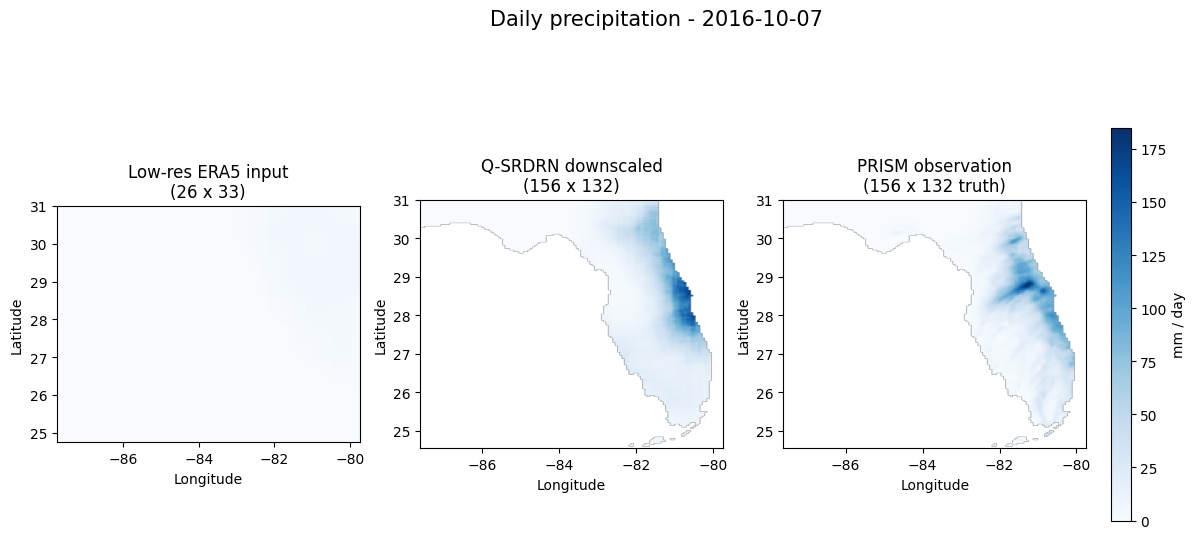

Total rain volume that day:
  Downscaled (sum over land): 144769.0 mm
  Observed   (sum over land): 126798.7 mm


In [29]:
# === Paths for the second dataset ===
DATA_DIR = '/Users/hnaja002/Documents/projects/summer camp/mydata_corrected_fl'
NC_PATH  = '/Users/hnaja002/Documents/projects/summer camp/test_precip_mm.nc'

# --- Load metadata ---
lr_lat   = np.load(f'{DATA_DIR}/low_res_lat.npy')
lr_lon   = np.load(f'{DATA_DIR}/low_res_lon.npy')
hr_lat   = np.load(f'{DATA_DIR}/high_res_lat.npy')
hr_lon_raw = np.load(f'{DATA_DIR}/high_res_lon.npy')
land_mask2 = np.load(f'{DATA_DIR}/land_mask.npy')
test_dates2 = np.load(f'{DATA_DIR}/test_dates.npy', allow_pickle=True)

print(f'Low-res  grid: {len(lr_lat)} x {len(lr_lon)}  (ERA5, 0.25 deg)')
print(f'High-res grid: {len(hr_lat)} x {len(hr_lon_raw)}  (PRISM, ~4 km)')
print(f'Test dates: {test_dates2[0]} to {test_dates2[-1]} ({len(test_dates2)} days)')

# --- Load low-res predictors (normalized) ---
pred_test = np.load(f'{DATA_DIR}/predictors_test_mean_std_separate.npy', mmap_mode='r')
lr_mean   = np.load(f'{DATA_DIR}/low_res_mean.npy')
lr_std    = np.load(f'{DATA_DIR}/low_res_std.npy')

# 'tp' (total precipitation) is the 7th variable (index 6)
TP_IDX = 6
tp_mean = lr_mean[..., TP_IDX]
tp_std  = lr_std[..., TP_IDX]

# --- Load high-res observations (normalized) and their stats ---
obs_test = np.load(f'{DATA_DIR}/obs_test_mean_std_single.npy', mmap_mode='r')
hr_mean2 = np.load(f'{DATA_DIR}/ERA5_mean_train.npy')
hr_std2  = np.load(f'{DATA_DIR}/ERA5_std_train.npy')

print(f'HR obs mean range (over land): [{hr_mean2[land_mask2].min():.3f}, {hr_mean2[land_mask2].max():.3f}]')
print(f'HR obs std  range (over land): [{hr_std2[land_mask2].min():.3f}, {hr_std2[land_mask2].max():.3f}]')

# --- Load Q-SRDRN downscaled output (already in mm/day) ---
ds_nc = xr.open_dataset(NC_PATH)
precip_nc = ds_nc.precip_mm  # keep as DataArray for easy date indexing

# --- Convert high-res lon from [0, 360] to [-180, 180] ---
hr_lon2 = np.where(hr_lon_raw > 180, hr_lon_raw - 360, hr_lon_raw)
extent_hr2 = [hr_lon2.min(), hr_lon2.max(), hr_lat.min(), hr_lat.max()]
extent_lr2 = [lr_lon.min(), lr_lon.max(), lr_lat.min(), lr_lat.max()]
'''
  - '2017-09-10' — Hurricane Irma
  - '2016-10-07' — Hurricane Matthew
  - '2017-09-11' — day after Irma
  - '2018-05-26' — Subtropical Storm Alberto
  - '2017-08-28' — calm summer day

'''
# --- Pick a day ---
# DAY2 = '2017-09-10'   # Hurricane Irma
DAY2 = '2016-10-07'   # Hurricane Irma

day_idx2 = np.where(test_dates2 == DAY2)[0][0]
target_date2 = np.datetime64(DAY2)

# Low-res: extract tp channel, denormalize (log1p was applied before z-score)
lr_tp_norm = pred_test[day_idx2, :, :, TP_IDX].copy()
lr_tp_log1p = lr_tp_norm * tp_std + tp_mean
lr_tp_mm = np.maximum(np.expm1(lr_tp_log1p), 0.0)

# Downscaled: read from netCDF (already mm/day)
sr_mm = precip_nc.sel(time=target_date2).values.copy()

# Truth: denormalize (log1p was applied before z-score)
obs_norm = obs_test[day_idx2].copy()
obs_log1p = obs_norm * hr_std2 + hr_mean2
obs_mm = np.maximum(np.expm1(obs_log1p), 0.0)
obs_mm[~land_mask2] = np.nan

# --- Plot ---
vmax2 = max(np.nanmax(sr_mm), np.nanmax(obs_mm), lr_tp_mm.max(), 5.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(lr_tp_mm, cmap='Blues', origin='lower',
               vmin=0, vmax=vmax2, extent=extent_lr2, interpolation='nearest')
axes[1].imshow(sr_mm,    cmap='Blues', origin='lower',
               vmin=0, vmax=vmax2, extent=extent_hr2)
axes[2].imshow(obs_mm,   cmap='Blues', origin='lower',
               vmin=0, vmax=vmax2, extent=extent_hr2)
axes[0].set_title(f'Low-res ERA5 input\n(26 x 33)')
axes[1].set_title(f'Q-SRDRN downscaled\n(156 x 132)')
axes[2].set_title(f'PRISM observation\n(156 x 132 truth)')
for ax in axes:
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
fig.suptitle(f'Daily precipitation - {DAY2}', fontsize=15, y=1.02)
cbar = fig.colorbar(axes[2].images[0], ax=axes, shrink=0.85, pad=0.02, label='mm / day')
plt.show()

print(f'Total rain volume that day:')
print(f'  Downscaled (sum over land): {np.nansum(sr_mm[land_mask2]):8.1f} mm')
print(f'  Observed   (sum over land): {np.nansum(obs_mm[land_mask2]):8.1f} mm')

ds_nc.close()

In [ ]:
# --- Group days by season ---
test_dt = pd.to_datetime(test_dates2)
months = np.asarray(test_dt.month)

seasons = [
    ('DJF (Winter)', [12, 1, 2]),
    ('MAM (Spring)', [3, 4, 5]),
    ('JJA (Summer)', [6, 7, 8]),
    ('SON (Fall)',   [9, 10, 11]),
]

lr_means   = []
sr_means   = []
obs_means  = []

for season_name, season_months in seasons:
    mask = np.isin(months, season_months)
    n_days = mask.sum()
    print(f'{season_name}: {n_days} days')

    # Low-res ERA5 tp: denormalize each day, THEN average
    lr_norm_season = pred_test[mask, :, :, TP_IDX]                    # (n_days, 26, 33)
    lr_mm_daily = np.maximum(np.expm1(lr_norm_season * tp_std + tp_mean), 0.0)
    lr_means.append(lr_mm_daily.mean(axis=0))

    # Downscaled: mean over time from .nc (already mm/day)
    sr_season = precip_nc.isel(time=mask).mean(dim='time').values     # (156, 132)
    sr_means.append(sr_season)

    # Obs: denormalize each day, THEN average
    obs_norm_season = obs_test[mask]                                   # (n_days, 156, 132)
    obs_mm_daily = np.maximum(np.expm1(obs_norm_season * hr_std2 + hr_mean2), 0.0)
    obs_mm_daily[:, ~land_mask2] = np.nan
    obs_means.append(np.nanmean(obs_mm_daily, axis=0))

# --- Plot: 4 rows x 3 columns ---
# ERA5: per-row auto-scale  |  Q-SRDRN + PRISM: per-row shared scale

fig, axes = plt.subplots(4, 3, figsize=(20, 22))

for row_idx, (season_name, _) in enumerate(seasons):
    lr_vmax = max(lr_means[row_idx].max(), 0.5)
    row_hr_vmax = max(np.nanmax(sr_means[row_idx]), np.nanmax(obs_means[row_idx]), 5.0)

    # Left: low-res ERA5
    im0 = axes[row_idx, 0].imshow(lr_means[row_idx], cmap='Blues', origin='lower',
                                   vmin=0, vmax=lr_vmax, extent=extent_lr2,
                                   interpolation='nearest')
    axes[row_idx, 0].set_title(f'{season_name} - ERA5 input', fontsize=11)
    axes[row_idx, 0].set_xlabel('Longitude'); axes[row_idx, 0].set_ylabel('Latitude')
    fig.colorbar(im0, ax=axes[row_idx, 0], location='right', shrink=0.7, pad=0.04, label='mm/day')

    # Middle: Q-SRDRN downscaled
    im1 = axes[row_idx, 1].imshow(sr_means[row_idx], cmap='Blues', origin='lower',
                                   vmin=0, vmax=row_hr_vmax, extent=extent_hr2)
    axes[row_idx, 1].set_title(f'{season_name} - Q-SRDRN downscaled', fontsize=11)
    axes[row_idx, 1].set_xlabel('Longitude'); axes[row_idx, 1].set_ylabel('Latitude')
    fig.colorbar(im1, ax=axes[row_idx, 1], location='right', shrink=0.7, pad=0.04, label='mm/day')

    # Right: PRISM observation
    im2 = axes[row_idx, 2].imshow(obs_means[row_idx], cmap='Blues', origin='lower',
                                   vmin=0, vmax=row_hr_vmax, extent=extent_hr2)
    axes[row_idx, 2].set_title(f'{season_name} - PRISM observation', fontsize=11)
    axes[row_idx, 2].set_xlabel('Longitude'); axes[row_idx, 2].set_ylabel('Latitude')
    fig.colorbar(im2, ax=axes[row_idx, 2], location='right', shrink=0.7, pad=0.04, label='mm/day')

fig.suptitle('Seasonal mean precipitation - Test period (2015-2019)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

---

## Step 5: Train-Period Seasonal Averages

To check whether the model captures the *climate* it was trained on, we repeat the seasonal average over the **training period (1981–2014)**. The model saw these 12,418 days during training, so the downscaled output here reflects what the model learned to reproduce — not an independent test.

*Note: loading the full training datasets (~2.8 GB total) may take a few seconds.*

In [ ]:
# --- Load training-period data ---
TRAIN_NC = '/Users/hnaja002/Documents/projects/summer camp/train_precip_mm.nc'

print('Loading train-period predictors ...')
pred_train = np.load(f'{DATA_DIR}/predictors_train_mean_std_separate.npy', mmap_mode='r')
print(f'  shape: {pred_train.shape}  (T, lat, lon, vars)')

print('Loading train-period observations ...')
obs_train = np.load(f'{DATA_DIR}/obs_train_mean_std_single.npy', mmap_mode='r')
print(f'  shape: {obs_train.shape}  (T, lat, lon)')

print('Loading train-period downscaled output ...')
ds_train_nc = xr.open_dataset(TRAIN_NC)
precip_train_nc = ds_train_nc.precip_mm
print(f'  shape: {precip_train_nc.shape}')

train_dates = np.load(f'{DATA_DIR}/train_dates.npy', allow_pickle=True)
print(f'Train dates: {train_dates[0]} to {train_dates[-1]} ({len(train_dates)} days)')

# --- Group by season ---
train_dt = pd.to_datetime(train_dates)
train_months = np.asarray(train_dt.month)

lr_train_means   = []
sr_train_means   = []
obs_train_means  = []

for season_name, season_months in seasons:
    mask = np.isin(train_months, season_months)
    n_days = mask.sum()
    print(f'{season_name}: {n_days} days')

    # Low-res ERA5 tp: denormalize each day, THEN average
    lr_norm_s = pred_train[mask, :, :, TP_IDX]                         # (n_days, 26, 33)
    lr_mm_daily = np.maximum(np.expm1(lr_norm_s * tp_std + tp_mean), 0.0)
    lr_train_means.append(lr_mm_daily.mean(axis=0))

    # Downscaled
    sr_s = precip_train_nc.isel(time=mask).mean(dim='time').values
    sr_train_means.append(sr_s)

    # Obs: denormalize each day, THEN average
    obs_norm_s = obs_train[mask]                                         # (n_days, 156, 132)
    obs_mm_daily = np.maximum(np.expm1(obs_norm_s * hr_std2 + hr_mean2), 0.0)
    obs_mm_daily[:, ~land_mask2] = np.nan
    obs_train_means.append(np.nanmean(obs_mm_daily, axis=0))

ds_train_nc.close()

# --- Plot: 4 rows x 3 columns ---
# ERA5: per-row auto-scale  |  Q-SRDRN + PRISM: per-row shared scale

fig, axes = plt.subplots(4, 3, figsize=(20, 22))

for row_idx, (season_name, _) in enumerate(seasons):
    lr_vmax = max(lr_train_means[row_idx].max(), 0.5)
    row_hr_vmax = max(np.nanmax(sr_train_means[row_idx]), np.nanmax(obs_train_means[row_idx]), 5.0)

    # Left: low-res ERA5
    im0 = axes[row_idx, 0].imshow(lr_train_means[row_idx], cmap='Blues', origin='lower',
                                   vmin=0, vmax=lr_vmax, extent=extent_lr2,
                                   interpolation='nearest')
    axes[row_idx, 0].set_title(f'{season_name} - ERA5 input', fontsize=11)
    axes[row_idx, 0].set_xlabel('Longitude'); axes[row_idx, 0].set_ylabel('Latitude')
    fig.colorbar(im0, ax=axes[row_idx, 0], location='right', shrink=0.7, pad=0.04, label='mm/day')

    # Middle: Q-SRDRN downscaled
    im1 = axes[row_idx, 1].imshow(sr_train_means[row_idx], cmap='Blues', origin='lower',
                                   vmin=0, vmax=row_hr_vmax, extent=extent_hr2)
    axes[row_idx, 1].set_title(f'{season_name} - Q-SRDRN downscaled', fontsize=11)
    axes[row_idx, 1].set_xlabel('Longitude'); axes[row_idx, 1].set_ylabel('Latitude')
    fig.colorbar(im1, ax=axes[row_idx, 1], location='right', shrink=0.7, pad=0.04, label='mm/day')

    # Right: PRISM observation
    im2 = axes[row_idx, 2].imshow(obs_train_means[row_idx], cmap='Blues', origin='lower',
                                   vmin=0, vmax=row_hr_vmax, extent=extent_hr2)
    axes[row_idx, 2].set_title(f'{season_name} - PRISM observation', fontsize=11)
    axes[row_idx, 2].set_xlabel('Longitude'); axes[row_idx, 2].set_ylabel('Latitude')
    fig.colorbar(im2, ax=axes[row_idx, 2], location='right', shrink=0.7, pad=0.04, label='mm/day')

fig.suptitle('Seasonal mean precipitation - Training period (1981-2014)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()